## 1. Setup

### 1.1 Install Dependecies

In [1]:
!pip install tensorflow opencv-python matplotlib

### 1.2 Import Dependencies

In [2]:
import os
import cv2
import random
import numpy as np
from matplotlib import pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Layer, Conv2D, Dense, MaxPooling2D, Input, Flatten

2025-03-14 18:04:30.821955: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-14 18:04:30.971977: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-14 18:04:33.006695: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


### 1.3 Set GPU

In [3]:
# Avoid OFM erreors by setting GPU Memory Computation Growth
'''gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)'''

"gpus = tf.config.experimental.list_physical_devices('GPU')\nfor gpu in gpus:\n    tf.config.experimental.set_memory_growth(gpu, True)"

### 1.4 Creating Folder Strucutres

In [3]:
# Stepups Paths
POS_PATH = os.path.join('data', 'positive') # Positive verification Images
NEG_PATH = os.path.join('data', 'negative') # Negative verification Images
ANC_PATH = os.path.join('data', 'anchor') # Entered Image to be verified

In [4]:
# Make the directories
os.makedirs(POS_PATH)
os.makedirs(NEG_PATH)
os.makedirs(ANC_PATH)

## 2. Collect Positives and Anchors

### 2.1 Untar Labelled Faces in the Wild Dataset

In [4]:
# Uncompress Taz GZ Laballes Faces in the Wild Dataset
!tar -xf lfw.tgz

In [5]:
# Move the LFW Images to the following repository data/negative
for directory in os.listdir('lfw'):
    for file in os.listdir(os.path.join('lfw', directory)):
        EX_PATH = os.path.join('lfw', directory, file)
        NEW_PATH = os.path.join(NEG_PATH, file)
        os.replace(EX_PATH, NEW_PATH)

In [6]:
# Here is to see what is actually happenning tin the cod above
for directory in os.listdir('lfw'):
    for file in os.listdir(os.path.join('lfw', directory)):
        print(file)

### 2.2 Collect Positve And Anchor Classes

**Here we will be using opencv to collect images of 250*250 pixels for the anchor and positives folder using the webcam. Here by defaut the image resolution and size will be diferent**

In [7]:
# Establish a connection to a webcam
cap = cv2.VideoCapture(0) #Use 0 for the webcam access
while cap.isOpened():
    ret, frame = cap.read()

    # Show the image to the screen
    cv2.imshow("Image Collection", frame)

    #Breaking gracefully
    if cv2.waitKey(1) & 0XFF == ord('q'):
        break

# Release the webcam
cap.release()
# Close the image show frame
cv2.destroyAllWindows()

qt.qpa.plugin: Could not find the Qt platform plugin "wayland" in "/home/redeus/.local/lib/python3.10/site-packages/cv2/qt/plugins"


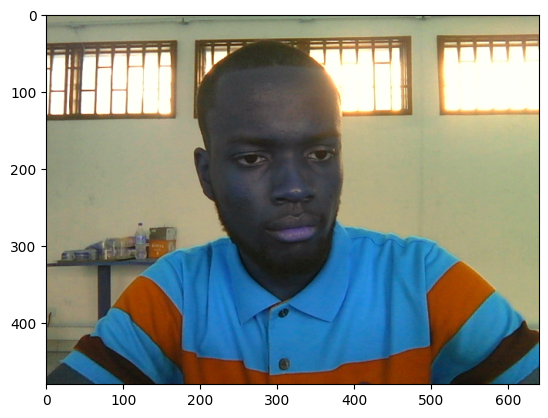

In [8]:
# the frame object to acces the last elements in of are video object
plt.imshow(frame) # the color is due to the the channels od the in opevc

In [9]:
frame.shape

(480, 640, 3)

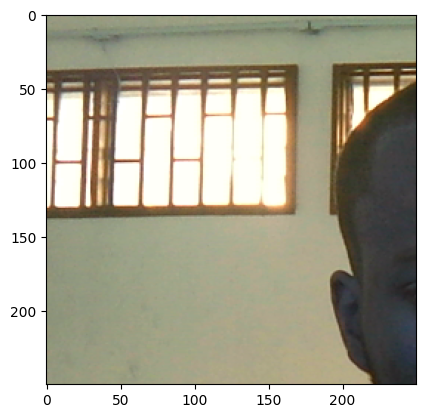

In [10]:
plt.imshow(frame[:250,:250, :])

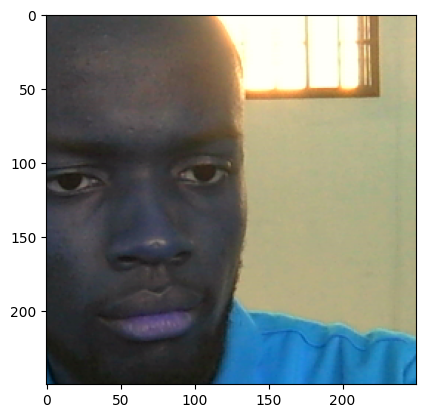

In [11]:
plt.imshow(frame[75:75+250,250:250+250, :]) # The colon at the end sigifies that we are passing through all the 3 channels

In [12]:
frame[75:75+250,250:250+250, :].shape

(250, 250, 3)

**Now lets implements that in our image grapping loop**

**The uuid library here will helps us to name our collocted images with unique names. uuid (uniforn, unique, identifiers)**

In [5]:
# Import uuid library to generate unique image names
import uuid

In [6]:
# Establish a connection to a webcam
cap = cv2.VideoCapture(0) #Use 0 for the webcam access
while cap.isOpened():
    ret, frame = cap.read()

    # Cut down frame to 250*250px
    frame = frame[75:75+250,250:250+250, :]

    # Collect anchors 
    if cv2.waitKey(1) & 0XFF == ord('a'):
        # Create the unique file path 
        imgname = os.path.join(ANC_PATH, '{}.jpg'.format(uuid.uuid1()))
        # Write out anchor image
        cv2.imwrite(imgname, frame)
    
    # Collect positives
    if cv2.waitKey(1) & 0XFF == ord('p'):
        # Create the unique file path 
        imgname = os.path.join(POS_PATH, '{}.jpg'.format(uuid.uuid1()))
        # Write out positive image
        cv2.imwrite(imgname, frame)

    # Show the image to the screen
    cv2.imshow("Image Collection", frame)

    #Breaking gracefully
    if cv2.waitKey(1) & 0XFF == ord('q'):
        break

# Release the webcam
cap.release()
# Close the image show frame
cv2.destroyAllWindows()

qt.qpa.plugin: Could not find the Qt platform plugin "wayland" in "/home/redeus/.local/lib/python3.10/site-packages/cv2/qt/plugins"


## 3. Load And Preprocess Images

### 3.1 Get Images Directories

In [56]:
anchor = tf.data.Dataset.list_files(ANC_PATH+'/*.jpg').take(300)
positive = tf.data.Dataset.list_files(POS_PATH+'/*.jpg').take(300)
negative = tf.data.Dataset.list_files(NEG_PATH+'/*.jpg').take(300)

In [57]:
ANC_PATH+'/*.jpg'

'data/anchor/*.jpg'

In [58]:
dir_test = anchor.as_numpy_iterator()

2025-03-14 18:51:54.526516: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [512]
	 [[{{node Placeholder/_0}}]]
2025-03-14 18:51:54.527531: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [512]
	 [[{{node Placeholder/_0}}]]


In [59]:
print(dir_test.next())

b'data/anchor/ec790ffd-00e3-11f0-8c8d-67a4e06dc050.jpg'


### 3.2 Preprocessing - Scale Resize

In [60]:
def preprocess(file_path):
    # Read in image from file path
    byte_img = tf.io.read_file(file_path)
    # Load in the image
    img = tf.io.decode_jpeg(byte_img)
    # Preprecessing steps - resizing the images to be 100 * 100 *3
    img = tf.image.resize(img, (100, 100))
    # Scalling the image between 0 and 1
    img = img / 255.0

    # Return our image
    return img

In [61]:
img = preprocess('data/anchor/6832fdb8-00e4-11f0-8c8d-67a4e06dc050.jpg')

In [63]:
img.numpy().min()

0.0

In [62]:
img.numpy().max()

1.0

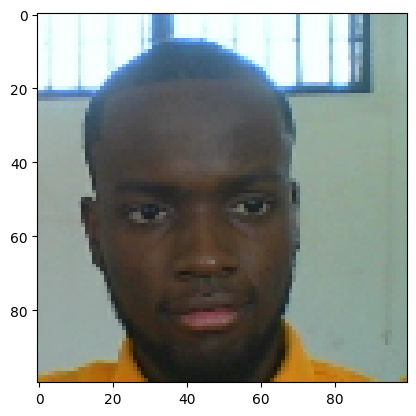

In [64]:
plt.imshow(img)

### 3.3 Create Labelled Dataset

In [66]:
# (anchor, positive) => 1,1,1,1,1
# (anchor, negative) => 0,0,0,0,0

tf.ones_like([1,1,1,4,35235,2352.5])

<tf.Tensor: shape=(6,), dtype=float32, numpy=array([1., 1., 1., 1., 1., 1.], dtype=float32)>

In [67]:
positives = tf.data.Dataset.zip((anchor, positive, tf.data.Dataset.from_tensor_slices(tf.ones(len(anchor)))))
negatives = tf.data.Dataset.zip((anchor, negative, tf.data.Dataset.from_tensor_slices(tf.zeros(len(anchor)))))
data = positives.concatenate(negatives)

In [68]:
samples = data.as_numpy_iterator()

2025-03-14 18:52:31.674278: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_9' with dtype string and shape [307]
	 [[{{node Placeholder/_9}}]]
2025-03-14 18:52:31.676097: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_39' with dtype float and shape [300]
	 [[{{node Placeholder/_39}}]]


In [69]:
example = samples.next()

In [70]:
example

(b'data/anchor/f5e6f8f4-00e3-11f0-8c8d-67a4e06dc050.jpg',
 b'data/positive/fd58171e-00e3-11f0-8c8d-67a4e06dc050.jpg',
 1.0)

### 3.4 Build Train and Test Partition

In [71]:
def preprocess_twin(input_img, validation_img, label):
    return(preprocess(input_img), preprocess(validation_img), label)

In [72]:
res = preprocess_twin(*example)

In [73]:
len(res)

3

In [74]:
res[0]

<tf.Tensor: shape=(100, 100, 3), dtype=float32, numpy=
array([[[0.9676471 , 1.        , 0.9911765 ],
        [0.96666664, 1.        , 0.9990196 ],
        [0.92941177, 1.        , 0.9941176 ],
        ...,
        [0.59289217, 0.6958333 , 0.6605392 ],
        [0.5921569 , 0.69803923, 0.66862744],
        [0.59117645, 0.6970588 , 0.6696078 ]],

       [[0.96862745, 1.        , 0.99215686],
        [0.96666664, 1.        , 0.9990196 ],
        [0.9311274 , 1.        , 0.99583334],
        ...,
        [0.589951  , 0.69289213, 0.657598  ],
        [0.59583336, 0.7017157 , 0.6723039 ],
        [0.59705883, 0.7029412 , 0.6754902 ]],

       [[0.96862745, 1.        , 0.99215686],
        [0.96666664, 1.        , 0.9990196 ],
        [0.93333334, 1.        , 0.9980392 ],
        ...,
        [0.5973039 , 0.7002451 , 0.66495097],
        [0.59117645, 0.6970588 , 0.66764706],
        [0.59607846, 0.7019608 , 0.6745098 ]],

       ...,

       [[0.59705883, 0.6379902 , 0.64142156],
        [0.61

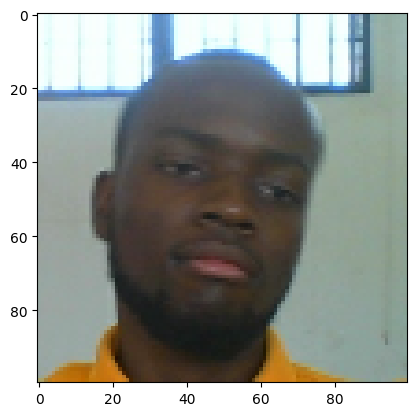

In [75]:
plt.imshow(res[0])

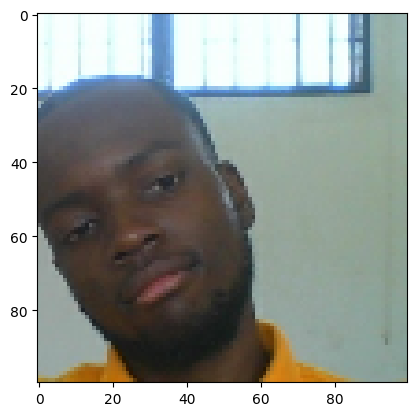

In [76]:
plt.imshow(res[1])

In [77]:
res[2]

1.0

In [78]:
# Build dataloader pipeline
data = data.map(preprocess_twin)
data = data.cache()
data = data.shuffle(buffer_size=1024)

In [79]:
sample = data.as_numpy_iterator()

2025-03-14 18:53:07.780823: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_30' with dtype string and shape [13233]
	 [[{{node Placeholder/_30}}]]
2025-03-14 18:53:07.782679: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_39' with dtype float and shape [300]
	 [[{{node Placeholder/_39}}]]


In [80]:
len(sample.next())

3

In [83]:
samp = sample.next()

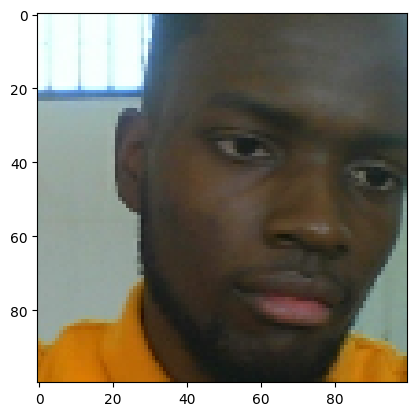

In [85]:
plt.imshow(samp[0])

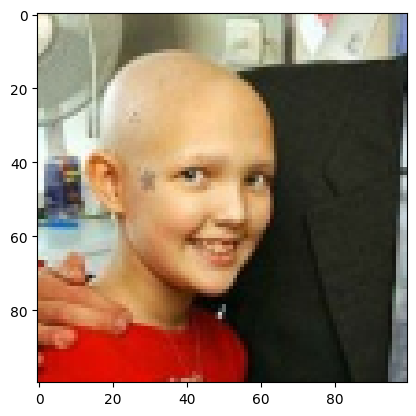

In [84]:
plt.imshow(samp[1])

In [86]:
samp[2]

0.0

In [88]:
(len(data)*.7)

420.0

In [89]:
data

<_ShuffleDataset element_spec=(TensorSpec(shape=(100, 100, None), dtype=tf.float32, name=None), TensorSpec(shape=(100, 100, None), dtype=tf.float32, name=None), TensorSpec(shape=(), dtype=tf.float32, name=None))>

In [87]:
# Training partition
train_data = data.take(round(len(data)*.7))
train_data = train_data.batch(16)
train_data = train_data.prefetch(8)

In [92]:
train_samples = train_data.as_numpy_iterator()

In [93]:
train_sample = train_samples.next()

In [94]:
len(train_sample[0])

16

In [95]:
round(len(data)*.3)

180

In [ ]:
# Testing partition
test_data = data.skip(round(len(data)*.7))
test_data = test_data.take(round(len(data)*.3))
test_data = test_data.batch(16)
test_data = test_data.prefetch(8)

## 4. Model Enginneering

### 4.1 Building Embedding Layer

In [96]:
inp = Input(shape=(100,100,3), name='input_image')

In [98]:
inp.shape

TensorShape([None, 100, 100, 3])

In [97]:
c1 = Conv2D(64, (10,10), activation='relu')(inp)

In [100]:
c1.shape

TensorShape([None, 91, 91, 64])

In [101]:
m1 = MaxPooling2D(64, (2,2), padding='same')(c1)

In [102]:
m1.shape

TensorShape([None, 46, 46, 64])

In [103]:
c2 = Conv2D(128, (7,7), activation='relu')(m1)
m2 = MaxPooling2D(64, (2,2), padding='same')(c2)

In [104]:
m2.shape

TensorShape([None, 20, 20, 128])

In [105]:
# Third block 
c3 = Conv2D(128, (4,4), activation='relu')(m2)
m3 = MaxPooling2D(64, (2,2), padding='same')(c3)

In [106]:
m3.shape

TensorShape([None, 9, 9, 128])

In [108]:
c4 = Conv2D(256, (4,4), activation='relu')(m3)

In [109]:
c4.shape

TensorShape([None, 6, 6, 256])

In [110]:
f1 = Flatten()(c4)
d1 = Dense(4096, activation='sigmoid')(f1)

2025-03-14 21:29:08.189177: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 150994944 exceeds 10% of free system memory.
2025-03-14 21:29:08.430581: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 150994944 exceeds 10% of free system memory.


In [111]:
f1

<KerasTensor: shape=(None, 9216) dtype=float32 (created by layer 'flatten_1')>

In [112]:
d1

<KerasTensor: shape=(None, 4096) dtype=float32 (created by layer 'dense_1')>

In [113]:
mod = Model(inputs=[inp], outputs=[d1], name= 'embedding')

In [114]:
mod.summary()

Model: "embedding"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_image (InputLayer)    [(None, 100, 100, 3)]     0         
                                                                 
 conv2d (Conv2D)             (None, 91, 91, 64)        19264     
                                                                 
 max_pooling2d (MaxPooling2D  (None, 46, 46, 64)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 40, 40, 128)       401536    
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 20, 20, 128)      0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 17, 17, 128)       26

In [115]:
def make_embedding():

    inp = Input(shape=(100,100,3), name='input_image')

    # First block
    c1 = Conv2D(64, (10,10), activation='relu')(inp)
    m1 = MaxPooling2D(64, (2,2), padding='same')(c1)
    
    # Second block
    c2 = Conv2D(128, (7,7), activation='relu')(m1)
    m2 = MaxPooling2D(64, (2,2), padding='same')(c2)
    
    # Third block 
    c3 = Conv2D(128, (4,4), activation='relu')(m2)
    m3 = MaxPooling2D(64, (2,2), padding='same')(c3)

    # Final embedding block
    c4 = Conv2D(256, (4,4), activation='relu')(m3)
    f1 = Flatten()(c4)
    d1 = Dense(4096, activation='sigmoid')(f1)

    return Model(inputs=[inp], outputs=[d1], name= 'embedding')

In [116]:
model = make_embedding()

In [117]:
model.summary()

Model: "embedding"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_image (InputLayer)    [(None, 100, 100, 3)]     0         
                                                                 
 conv2d_5 (Conv2D)           (None, 91, 91, 64)        19264     
                                                                 
 max_pooling2d_3 (MaxPooling  (None, 46, 46, 64)       0         
 2D)                                                             
                                                                 
 conv2d_6 (Conv2D)           (None, 40, 40, 128)       401536    
                                                                 
 max_pooling2d_4 (MaxPooling  (None, 20, 20, 128)      0         
 2D)                                                             
                                                                 
 conv2d_7 (Conv2D)           (None, 17, 17, 128)       26

### 4.2 Building Embedding Layer

In [120]:
class L1Dist(Layer):
    def __init__(self, **kwergs):
        super().__init__()

    def call(self, input_embedding, validation_embedding):
        return tf.math.abs(input_embedding - validation_embedding)

In [121]:
L1 = L1Dist()